# Analisis Volume Penjualan per Tingkat Diskon

Analisis difokuskan pada kategori dengan profit margin terendah di bulan April 2017.

## Metodologi

1. Memfilter transaksi pada kategori Teknologi.
2. Menghitung total `quantity` berdasarkan tingkat diskon.
3. Memvisualisasikan volume penjualan pada setiap tingkat diskon.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

# load data
df = pd.read_pickle('superstore.pkl')

# order_date
order_str = df['order_date'].map(lambda x: type(x) == str)
order_no_str = df['order_date'].map(lambda x: type(x) != str)

df.loc[order_str, 'order_date'] = df.loc[order_str, 'order_date'].map(lambda x: '-'.join([i.zfill(2) for i in x.split('/')]))
df.loc[order_no_str, 'order_date'] = (df.loc[order_no_str, 'order_date'].astype(str)
                                      .map(lambda x: '-'.join(x.split()[0].split('-')[::-1])))
df['order_date'] = pd.to_datetime(df['order_date'], format='%m-%d-%Y', errors='coerce')

# ship_date
ship_str = df['ship_date'].map(lambda x: type(x) == str)
ship_no_str = df['ship_date'].map(lambda x: type(x) != str)

df.loc[ship_str, 'ship_date'] = df.loc[ship_str, 'ship_date'].map(lambda x: '-'.join([i.zfill(2) for i in x.split('/')]))
df.loc[ship_no_str, 'ship_date'] = (df.loc[ship_no_str, 'ship_date'].astype(str)
                                    .map(lambda x: '-'.join(x.split()[0].split('-')[::-1])))
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%m-%d-%Y', errors='coerce')

# order_month
month = ['January', 'February', 'March', 'April', 'May', 'June',
         'July', 'August', 'September', 'October', 'November', 'December']
df['order_month'] = pd.Categorical(df['order_date'].dt.strftime('%B'), categories=month, ordered=True)

# order_year
df['order_year'] = df['order_date'].dt.year

## Filter Data April 2017

Data difokuskan pada transaksi bulan April 2017 sebagai bulan dengan profit margin terendah.

In [2]:
df_april = df[(df['order_year'] == 2017) & (df['order_month'] == 'April')]

## Filter Data Kategori Teknologi

Data difokuskan pada kategori Teknologi yang mengalami kerugian pada bulan April 2017.

In [3]:
df_tech = df_april[df_april['category'] == 'Technology']

## Hitung Total Quantity per Tingkat Diskon

Data dikelompokkan berdasarkan `discount`, lalu dihitung total `quantity` untuk setiap tingkat diskon.

In [4]:
df_agg = df_tech.pivot_table(index='discount', values='quantity', aggfunc='sum').astype(int)
df_agg.index = [int(discount * 100) for discount in df_agg.index]
df_agg.index.name = 'discount'

df_agg

,quantity
discount,
0,38
20,39
40,8
70,5


## Visualisasi Volume Penjualan per Tingkat Diskon

Menampilkan total `quantity` per tingkat diskon untuk kategori Teknologi pada bulan April 2017.

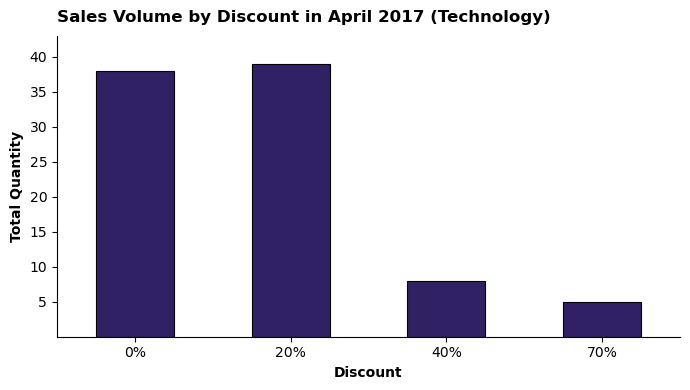

In [5]:
plt.figure(figsize=(7,4))
fig = sns.barplot(x=df_agg.index, y=df_agg['quantity'], color='#2A1470', ls='-', lw=0.8, ec='black', alpha=1)

for bar in fig.patches:
    bar.set_width(0.5)
    bar.set_xy((bar.get_xy()[0]+0.15, 0))

title_dict = {'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'left',
              'rotation':0,
              'pad':10,
              'alpha':1,
              'family':plt.rcParams['font.family']}

label_dict = {'x':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'alpha':1,
              'family':plt.rcParams['font.family']},
              
              'y':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'alpha':1,
              'family':plt.rcParams['font.family']}}

plt.title('Sales Volume by Discount in April 2017 (Technology)', **title_dict)
plt.xlabel('Discount', **label_dict['x'])
plt.ylabel('Total Quantity', **label_dict['y'])

ax = plt.gca()
ax.set_yticks(ticks=ax.get_yticks()[1:-1])
ax.set_ylim(0, 43)
ticks, _ = plt.xticks()
labels = [f'{int(discount)}%' for discount in df_agg.index]
plt.xticks(ticks=ticks, labels=labels)

plt.tight_layout()
sns.despine(left=False, top=True, right=True, bottom=False)
plt.show()